In [ ]:
#  — Model Comparison
# Compare heuristic and machine-learning approaches to link prediction using the same evaluation methodology.
# The same 20% hold-out strategy and random state used in evaluation are reproduced to ensure consistency.

# — Import libraries and set parameters

import random
import numpy as np
import pandas as pd
import networkx as nx

from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


RANDOM_STATE = 42
TEST_SIZE = 0.20
TOP_K = 100

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


# Load the validated edge-list

edges = pd.read_csv(
    "../facebook/0.edges",
    sep=" ",
    header=None,
    names=["source", "target"]
)


# — Construct the network

G = nx.Graph()

G.add_edges_from(
    edges[["source", "target"]].itertuples(
        index=False,
        name=None
    )
)


# — Recreate the same training and test split

all_edges = list(G.edges())

random.shuffle(all_edges)

test_size = int(len(all_edges) * TEST_SIZE)

test_edges = all_edges[:test_size]
train_edges = all_edges[test_size:]


G_train = nx.Graph()

G_train.add_nodes_from(G.nodes())
G_train.add_edges_from(train_edges)


positive_edges = {
    tuple(sorted(edge))
    for edge in test_edges
}


candidate_non_edges = list(nx.non_edges(G_train))

negative_edges = [
    edge
    for edge in candidate_non_edges
    if tuple(sorted(edge)) not in positive_edges
][:len(test_edges)]


candidate_edges = (
    list(positive_edges)
    + negative_edges
)


print(f"Network nodes: {G.number_of_nodes():,}")
print(f"Network edges: {G.number_of_edges():,}")
print(f"Training edges: {G_train.number_of_edges():,}")
print(f"Withheld test edges: {len(test_edges):,}")

Network nodes: 333
Network edges: 2,519
Training edges: 2,016
Withheld test edges: 503


In [ ]:
# — Generate heuristic and machine-learning predictions
# All network features are calculated from G_train.
# The withheld test relationships remain unseen.


# Generate heuristic scores

jaccard = {
    tuple(sorted((u, v))): score
    for u, v, score in nx.jaccard_coefficient(
        G_train,
        ebunch=candidate_edges
    )
}


adamic_adar = {
    tuple(sorted((u, v))): score
    for u, v, score in nx.adamic_adar_index(
        G_train,
        ebunch=candidate_edges
    )
}


common_neighbours = {
    tuple(sorted((u, v))): len(
        list(nx.common_neighbors(G_train, u, v))
    )
    for u, v in candidate_edges
}


# Create machine-learning training examples

training_positive = list(G_train.edges())

training_positive_set = {
    tuple(sorted(edge))
    for edge in training_positive
}


# Negative examples are sampled from node pairs that are not connected in the training graph.
# An equal number of negative and positive examples is used to create a balanced machine-learning training dataset.
# These examples are generated from G_train only.
# The withheld test relationships remain reserved for evaluation.

training_negative = set()

nodes = list(G_train.nodes())

while len(training_negative) < len(training_positive):

    u, v = random.sample(nodes, 2)

    pair = tuple(sorted((u, v)))

    if pair not in training_positive_set:
        training_negative.add(pair)


training_negative = list(training_negative)


training_data = pd.DataFrame(
    training_positive + training_negative,
    columns=["source", "target"]
)

training_data["label"] = (
    [1] * len(training_positive)
    + [0] * len(training_negative)
)


# Calculate network features

degree = dict(G_train.degree())


def calculate_features(source, target):

    source_neighbours = set(G_train.neighbors(source))
    target_neighbours = set(G_train.neighbors(target))

    common = source_neighbours.intersection(
        target_neighbours
    )

    union = source_neighbours.union(
        target_neighbours
    )

    common_count = len(common)

    jaccard_score = (
        common_count / len(union)
        if len(union) > 0
        else 0
    )

    adamic_adar_score = sum(
        1 / np.log(degree[node])
        for node in common
        if degree[node] > 1
    )

    return [
        common_count,
        jaccard_score,
        adamic_adar_score,
        degree[source],
        degree[target]
    ]


feature_columns = [
    "common_neighbours",
    "jaccard",
    "adamic_adar",
    "source_degree",
    "target_degree"
]


def create_features(data):

    return pd.DataFrame(
        [
            calculate_features(
                row.source,
                row.target
            )
            for row in data.itertuples()
        ],
        columns=feature_columns
    )


X_train = create_features(training_data)
y_train = training_data["label"]


test_data = pd.DataFrame(
    candidate_edges,
    columns=["source", "target"]
)

X_test = create_features(test_data)

y_test = pd.Series([
    1 if tuple(sorted(edge)) in positive_edges else 0
    for edge in candidate_edges
])


#  Train Logistic Regression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=1000
        )
    )
])

logistic_model.fit(X_train, y_train)


# Train Random Forest

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)


# Generate ML prediction scores

logistic_scores = (
    logistic_model.predict_proba(X_test)[:, 1]
)

random_forest_scores = (
    random_forest_model.predict_proba(X_test)[:, 1]
)


print("Heuristic and machine-learning predictions generated.")

Heuristic and machine-learning predictions generated.


In [ ]:
# -Compare heuristic and machine-learning performance
# ROC-AUC measures discrimination across all prediction
# thresholds.
# Precision@100, Recall@100 and F1@100 assess the quality
# of the highest-ranked predictions.


evaluation_df = pd.DataFrame({
    "edge": [
        tuple(sorted(edge))
        for edge in candidate_edges
    ],
    "label": y_test,
    "Jaccard": [
        jaccard[tuple(sorted(edge))]
        for edge in candidate_edges
    ],
    "Adamic–Adar": [
        adamic_adar[tuple(sorted(edge))]
        for edge in candidate_edges
    ],
    "Common Neighbours": [
        common_neighbours[tuple(sorted(edge))]
        for edge in candidate_edges
    ],
    "Logistic Regression": logistic_scores,
    "Random Forest": random_forest_scores
})


# Calculate comparison metrics

comparison_results = []

methods = [
    "Jaccard",
    "Adamic–Adar",
    "Common Neighbours",
    "Logistic Regression",
    "Random Forest"
]


for method in methods:

    auc = roc_auc_score(
        evaluation_df["label"],
        evaluation_df[method]
    )

    ranked = (
        evaluation_df
        .sort_values(
            method,
            ascending=False
        )
        .head(TOP_K)
    )

    true_positives = sum(
        ranked["label"] == 1
    )

    precision_at_k = (
        true_positives / TOP_K
    )

    recall_at_k = (
        true_positives / len(positive_edges)
    )

    f1_at_k = (
        2 * precision_at_k * recall_at_k
        / (precision_at_k + recall_at_k)
        if precision_at_k + recall_at_k > 0
        else 0
    )

    comparison_results.append({
        "Method": method,
        "ROC-AUC": auc,
        "Precision@100": precision_at_k,
        "Recall@100": recall_at_k,
        "F1@100": f1_at_k
    })


comparison_results = (
    pd.DataFrame(comparison_results)
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)


print("Model Comparison")
print("=" * 50)

comparison_results

Model Comparison


,Method,ROC-AUC,Precision@100,Recall@100,F1@100
0,Adamic–Adar,0.943919,1.00,0.198807,0.331675
1,Logistic Regression,0.940538,0.98,0.194831,0.325041
2,Common Neighbours,0.937097,1.00,0.198807,0.331675
3,Random Forest,0.929333,0.99,0.196819,0.328358
4,Jaccard,0.928795,0.98,0.194831,0.325041


In [ ]:

#  — SNA TOOL
# Provide a simple analytical tool for exploring the network
# and identifying important users and network characteristics.


# Generate network-level summary statistics

network_summary = pd.DataFrame({
    "Measure": [
        "Number of users",
        "Number of relationships",
        "Network density",
        "Average degree",
        "Average clustering coefficient",
        "Number of connected components"
    ],
    "Value": [
        G.number_of_nodes(),
        G.number_of_edges(),
        nx.density(G),
        sum(dict(G.degree()).values()) / G.number_of_nodes(),
        nx.average_clustering(G),
        nx.number_connected_components(G)
    ]
})


network_summary

,Measure,Value
0,Number of users,333.000000
1,Number of relationships,2519.000000
2,Network density,0.045570
3,Average degree,15.129129
4,Average clustering coefficient,0.508245
5,Number of connected components,5.000000


In [5]:
# — Display available users
# This cell prints how many users and a range that can be changed
available_users = sorted(G.nodes())

print(f"Number of users available: {len(available_users):,}")
print("Example user IDs:")
print(available_users[:10])

Number of users available: 333
Example user IDs:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [ ]:
# — Create a user-level SNA analysis function
# The function reports the user's network position using
# degree, centrality and clustering measures.


degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
closeness_centrality = nx.closeness_centrality(G)
clustering_coefficient = nx.clustering(G)


def analyse_user(user_id):

    if user_id not in G:
        print(f"User {user_id} was not found in the network.")
        return

    result = pd.DataFrame({
        "Measure": [
            "Direct connections",
            "Degree centrality",
            "Betweenness centrality",
            "Closeness centrality",
            "Clustering coefficient"
        ],
        "Value": [
            G.degree(user_id),
            degree_centrality[user_id],
            betweenness_centrality[user_id],
            closeness_centrality[user_id],
            clustering_coefficient[user_id]
        ]
    })

    print(f"SNA Profile for User {user_id}")
    print("=" * 40)

    return result


# Example
# a default user is used . It can be changed to any of choice
analyse_user(1)

SNA Profile for User 1


,Measure,Value
0,Direct connections,16.000000
1,Degree centrality,0.048193
2,Betweenness centrality,0.004335
3,Closeness centrality,0.301867
4,Clustering coefficient,0.341667


In [7]:
# — Recommend potential connections for a user
# Adamic–Adar is used to rank potential connections.
# The model can be changed after the final model comparison.


def recommend_connections(user_id, top_n=10):

    if user_id not in G:
        print(f"User {user_id} was not found in the network.")
        return

    recommendations = []

    for u, v, score in nx.adamic_adar_index(
        G,
        ebunch=[
            (user_id, node)
            for node in G.nodes()
            if node != user_id
            and not G.has_edge(user_id, node)
        ]
    ):

        recommendations.append({
            "User": v,
            "Adamic–Adar Score": score
        })


    recommendations = (
        pd.DataFrame(recommendations)
        .sort_values(
            "Adamic–Adar Score",
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )


    recommendations.index += 1

    return recommendations


# Example
# a default user is used . It can be changed to any of choice
recommend_connections(1, top_n=10)

,User,Adamic–Adar Score
1,80,2.243960
2,302,2.198351
3,242,2.194567
4,130,1.958738
5,271,1.955411
6,180,1.948808
7,94,1.869892
8,249,1.869892
9,25,1.819196
10,26,1.626952


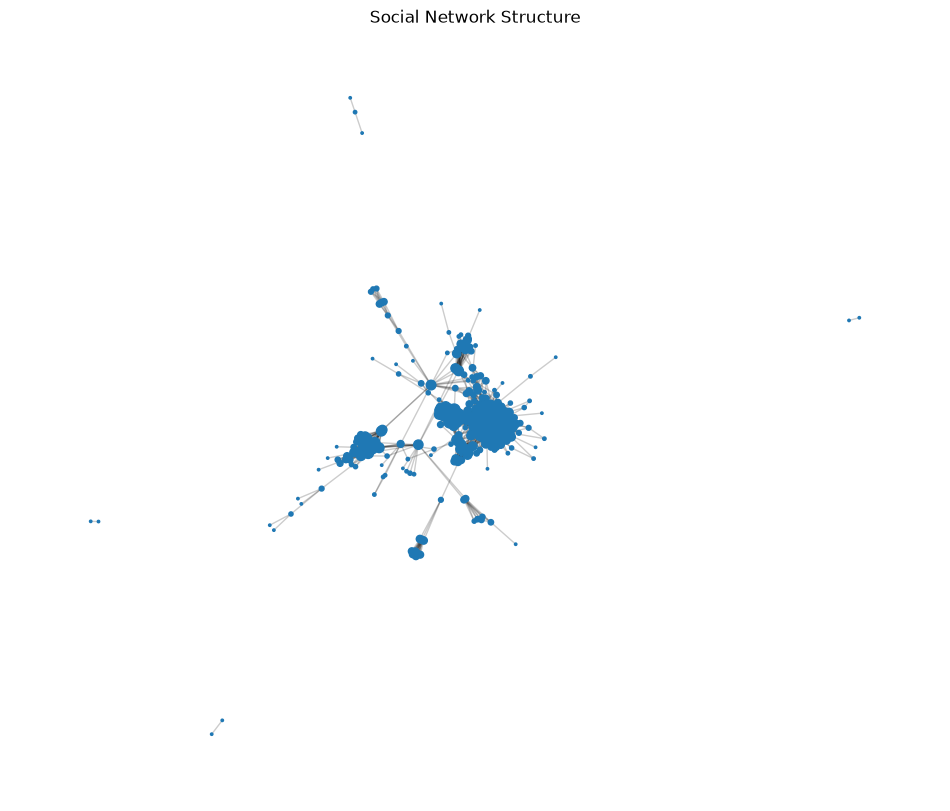

In [8]:
# — Visualise the social network
# Node size represents degree centrality.
# Larger nodes therefore indicate users with more direct
# connections within the network.


import matplotlib.pyplot as plt


plt.figure(figsize=(12, 10))


# Use a spring layout to position connected users together

pos = nx.spring_layout(
    G,
    seed=RANDOM_STATE
)


# Calculate node sizes from degree centrality

node_sizes = [
    1000 * degree_centrality[node]
    for node in G.nodes()
]


nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.2
)


nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes
)


plt.title(
    "Social Network Structure"
)

plt.axis("off")

plt.show()

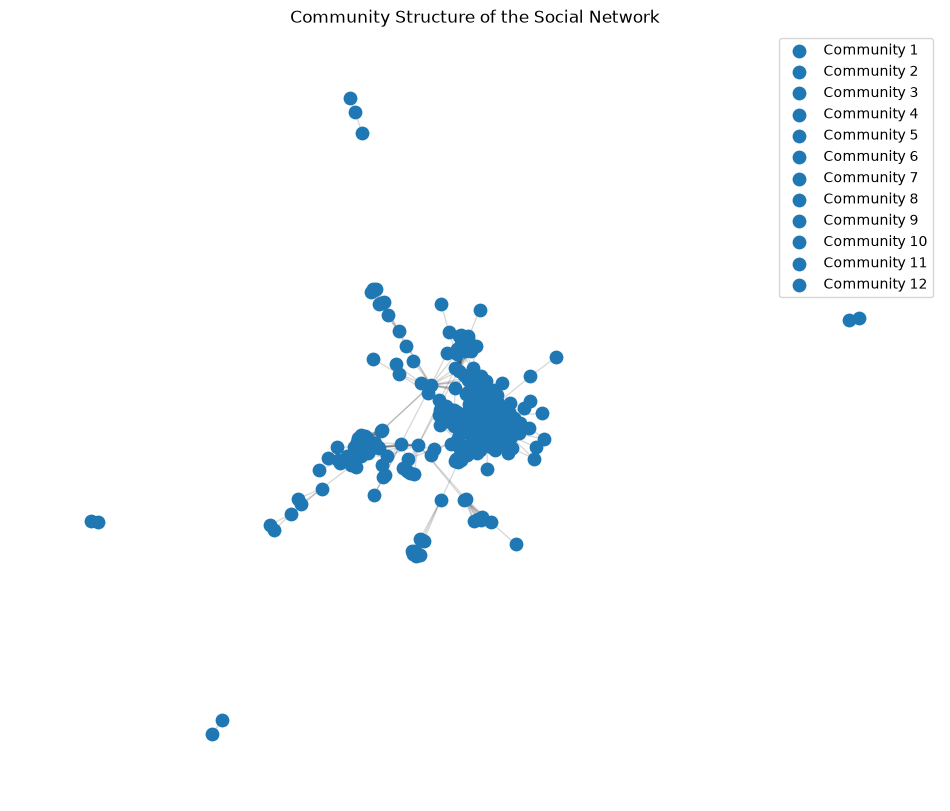

In [9]:
# — Visualise community structure
# Nodes belonging to the same detected community are positioned
# together to make the major groups within the network easier to interpret.

# Use the communities identified during network analysis

communities = list(
    nx.community.greedy_modularity_communities(G)
)


community_map = {}

for community_id, community in enumerate(communities):

    for node in community:

        community_map[node] = community_id


pos = nx.spring_layout(
    G,
    seed=RANDOM_STATE
)


plt.figure(figsize=(12, 10))


# Draw network edges

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.15
)


# Draw nodes according to their community

for community_id, community in enumerate(communities):

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=list(community),
        node_size=80,
        label=f"Community {community_id + 1}"
    )


plt.title(
    "Community Structure of the Social Network"
)

plt.legend()

plt.axis("off")

plt.show()

In [10]:
# — Integrated SNA user analysis
# This function combines the main user-level SNA measures
# and potential connection recommendations into one analysis.


def sna_tool(user_id, top_n=10):

    if user_id not in G:

        print(
            f"User {user_id} was not found in the network."
        )

        return


    print("=" * 50)
    print(f"SNA TOOL — USER {user_id}")
    print("=" * 50)


    # — Display user-level network measures

    profile = analyse_user(user_id)

    display(profile)


    # — Display recommended connections

    print()
    print("Recommended Potential Connections")
    print("=" * 50)

    recommendations = recommend_connections(
        user_id,
        top_n=top_n
    )

    display(recommendations)


# Example

sna_tool(1, top_n=10)

SNA TOOL — USER 1
SNA Profile for User 1


,Measure,Value
0,Direct connections,16.000000
1,Degree centrality,0.048193
2,Betweenness centrality,0.004335
3,Closeness centrality,0.301867
4,Clustering coefficient,0.341667



Recommended Potential Connections


,User,Adamic–Adar Score
1,80,2.243960
2,302,2.198351
3,242,2.194567
4,130,1.958738
5,271,1.955411
6,180,1.948808
7,94,1.869892
8,249,1.869892
9,25,1.819196
10,26,1.626952
